# 02. Очистка, признаки, утечки и сплит

Здесь рименяем очистку, генерируем признаки, показываем на эксперименте,
почему три колонки пришлось удалить и почему обычный случайный сплит здесь врёт,
и обосновываем выбор метрики

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from src.config import TARGET
from src.data.clean import clean_data, missing_report
from src.data.features import build_features, get_feature_columns, strip_prices
from src.data.load import load_raw
from src.data.split import add_listing_group, check_leakage, split_data
from src.models.baseline import LOW_CARD_CATEGORICAL, RAW_NUMERIC, build_models, build_preprocessor
from src.models.evaluate import compute_metrics, format_metrics, metrics_table
from src.utils.seed import set_seed
from src.utils.warnings import silence_blas_warnings
from src.viz import plots

silence_blas_warnings()
set_seed()
pd.set_option("display.max_columns", 60)

/Users/dianochka_l/Desktop/Project_ML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Очистка

Все шаги описаны в `src/data/clean.py`, каждый логирует, сколько строк потерял.
Эти цифры идут в отчёт как таблица «было → стало».

In [2]:
raw = load_raw()
clean = clean_data(raw)

print(f"\nБыло:  {raw.shape[0]:>6} строк, {raw.shape[1]} колонок")
print(f"Стало: {clean.shape[0]:>6} строк, {clean.shape[1]} колонок")
print(f"Потеряли {100 * (1 - len(clean) / len(raw)):.2f}% строк")

20:42:01 | INFO    | src.data.load | CSV уже распакован: /Users/dianochka_l/Desktop/Project_ML/data/raw/apartments_for_rent_classified_100K.csv
20:42:01 | INFO    | src.data.load | Загрузил сырые данные: 99492 строк, 22 колонок
20:42:01 | INFO    | src.data.clean | Очистка: на входе 99492 строк
20:42:01 | INFO    | src.data.clean | полные дубли                 -   84 строк -> 99408
20:42:01 | INFO    | src.data.clean | дубли по id                  -    0 строк -> 99408
20:42:01 | INFO    | src.data.clean | Типы приведены
20:42:01 | INFO    | src.data.clean | Пересчитал недельные цены в месячные: 3 строк
20:42:01 | INFO    | src.data.clean | пропущенный таргет           -    1 строк -> 99407
20:42:01 | INFO    | src.data.clean | пропущенное гео              -  302 строк -> 99105
20:42:01 | INFO    | src.data.clean | bathrooms                    заполнено медианой 1.0 (59 строк)
20:42:01 | INFO    | src.data.clean | bedrooms                     заполнено медианой 2.0 (124 строк)
20:42:01

In [3]:
# После очистки пропусков быть не должно
missing_report(clean).head(10)

,n_missing,pct_missing,dtype,n_unique
id,0,0.0,int64,99025
category,0,0.0,string,7
time,0,0.0,int64,75166
source,0,0.0,string,25
longitude,0,0.0,float64,7252
latitude,0,0.0,float64,7194
state,0,0.0,string,51
cityname,0,0.0,object,2977
square_feet,0,0.0,int64,2497
price_type,0,0.0,string,2


Потеряно меньше половины процента строк — очистка получилась консервативной:
мы удаляли только то, что нельзя восстановить (гео, таргет) или что заведомо
является ошибкой ввода (цена вне диапазона 200–10 000 \$).

## 2. Утечка таргета: эксперимент, а не рассуждение

В датасете есть колонка `price_display` — та же цена, но строкой: `$2,195`.
Проверим, что будет, если её не заметить и оставить в признаках.

In [4]:
demo = clean.copy()
demo["price_display_num"] = (
    demo["price_display"].astype(str)
    .str.extract(r"\$?\s*([\d,]+)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

print("Примеры проблемного парсинга:")
print(demo.loc[demo["price_display"].str.contains(" - ", na=False),
               ["price", "price_display", "price_display_num"]].head(3))
print()
print("Корреляция price_display_num с price:",
      round(demo[["price", "price_display_num"]].corr().iloc[0, 1], 6))

Примеры проблемного парсинга:
        price    price_display  price_display_num
50128  1782.0  $1,782 - $1,917             1782.0
50129  2882.0  $2,882 - $3,312             2882.0
50147   810.0    $810 - $1,025              810.0

Корреляция price_display_num с price: 0.999693


In [5]:
train_demo = demo.sample(frac=0.8, random_state=42)
test_demo = demo.drop(train_demo.index)

results_leak = {}
for name, features in [
    ("с price_display (утечка)", RAW_NUMERIC + ["price_display_num"]),
    ("без price_display", RAW_NUMERIC),
]:
    model = Pipeline([
        ("prep", build_preprocessor(features)),
        ("model", LinearRegression()),
    ]).fit(train_demo[features], train_demo[TARGET])

    metrics = compute_metrics(test_demo[TARGET].to_numpy(), model.predict(test_demo[features]))
    results_leak[name] = metrics
    print(f"{name:26s} {format_metrics(metrics)}")

metrics_table(results_leak)

с price_display (утечка)   MAE=0.3$ | RMSE=20.1$ | MAPE=0.0% | R2=0.999
без price_display          MAE=485.6$ | RMSE=686.5$ | MAPE=35.8% | R2=0.194


,mae,rmse,mape,r2,median_ae
с price_display (утечка),0.295,20.141,0.015,0.999,0.120
без price_display,485.650,686.457,35.790,0.194,380.183


**Результат:** с `price_display` модель даёт R2 = 0.999 и MAE меньше доллара, без неё — R2 = 0.19.
Это не «отличная модель», это модель, которая читает ответ из соседней колонки

По той же причине удаляем `price_type` и `currency` — они описывают единицы измерения таргета.
Список зафиксирован в `src/config.py: LEAKY_COLUMNS` и удаляется автоматически в `build_features`

Цена почти всегда упоминается в теле объявления. Сейчас, пока мы берём от текста только длину, но в CP2 будет TF-IDF,
и тогда модель прочитает цену из текста. Поэтому функция `strip_prices` вырезает упоминания цены заранее.

In [6]:
example = "Beautiful 2BR apartment! Only $1,250 / month. Call now — 1250$ special offer."
print("до: ", example)
print("после:", strip_prices(example))

до:  Beautiful 2BR apartment! Only $1,250 / month. Call now — 1250$ special offer.
после: Beautiful 2BR apartment! Only   / month. Call now — 1250$ special offer.


## 3. Генерация признаков

Из 21 исходной колонки пригодных «как есть» числовых всего пять.
`build_features` разворачивает мультиселекты, текст, гео и время.

In [7]:
df = build_features(clean)
df = add_listing_group(df)

numeric, categorical = get_feature_columns(df, target=TARGET)
categorical = [c for c in categorical if c in LOW_CARD_CATEGORICAL]

print(f"Было признаков (исходных числовых): {len(RAW_NUMERIC)}")
print(f"Стало: {len(numeric)} числовых + {len(categorical)} категориальных")

20:42:02 | INFO    | src.data.features | Feature engineering: на входе 22 колонок
20:42:02 | INFO    | src.data.features | Добавил 27 флагов удобств
20:42:07 | INFO    | src.data.features | Добавил текстовые признаки
20:42:07 | INFO    | src.data.features | Удалил колонки с утечкой таргета: price_display, price_type, currency
20:42:07 | INFO    | src.data.features | Feature engineering: на выходе 71 колонок
20:42:07 | INFO    | src.data.split | Групп объектов: 62046 при 99025 объявлениях (в среднем 1.60 объявления на объект)
Было признаков (исходных числовых): 5
Стало: 55 числовых + 5 категориальных


In [8]:
groups = {
    "удобства (am_*)": [c for c in numeric if c.startswith("am_")],
    "питомцы (pets_*)": [c for c in numeric if c.startswith("pets_")],
    "текст": [c for c in numeric if c.startswith(("title_", "body_", "text_"))],
    "производные от площади/комнат": [
        "is_studio", "sqft_per_bedroom", "bath_per_bedroom",
        "total_rooms", "sqft_per_room", "log_square_feet",
    ],
    "гео": ["latitude", "longitude", "city_listing_count", "state_listing_count",
            "lat_lon_interaction"],
    "время": ["month", "quarter", "dayofweek"],
}
for name, columns in groups.items():
    print(f"{name:32s} {len(columns):>3}  {', '.join(columns[:4])}...")

удобства (am_*)                   27  am_parking, am_pool, am_gym, am_patio_deck...
питомцы (pets_*)                   3  pets_cats, pets_dogs, pets_not_specified...
текст                              6  title_len, body_len, body_word_count, title_word_count...
производные от площади/комнат      6  is_studio, sqft_per_bedroom, bath_per_bedroom, total_rooms...
гео                                5  latitude, longitude, city_listing_count, state_listing_count...
время                              3  month, quarter, dayofweek...


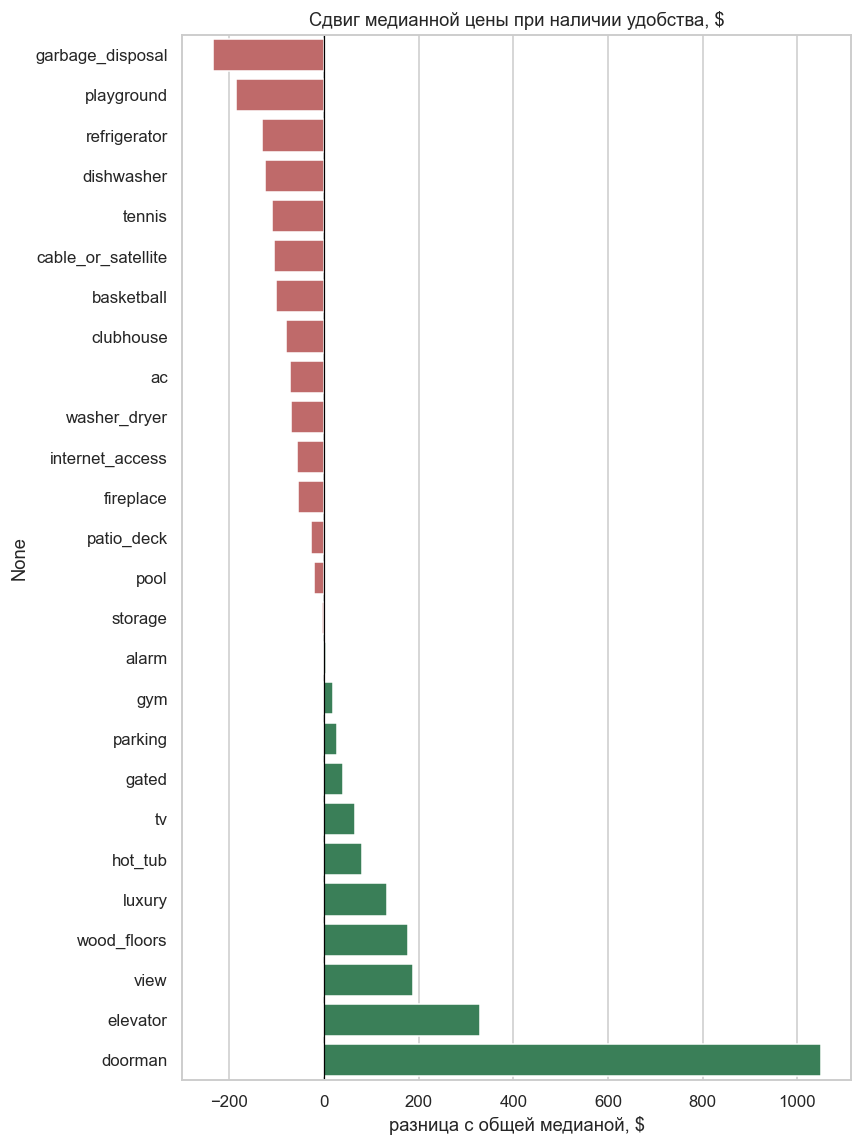

In [9]:
plots.plot_amenities_effect(df);

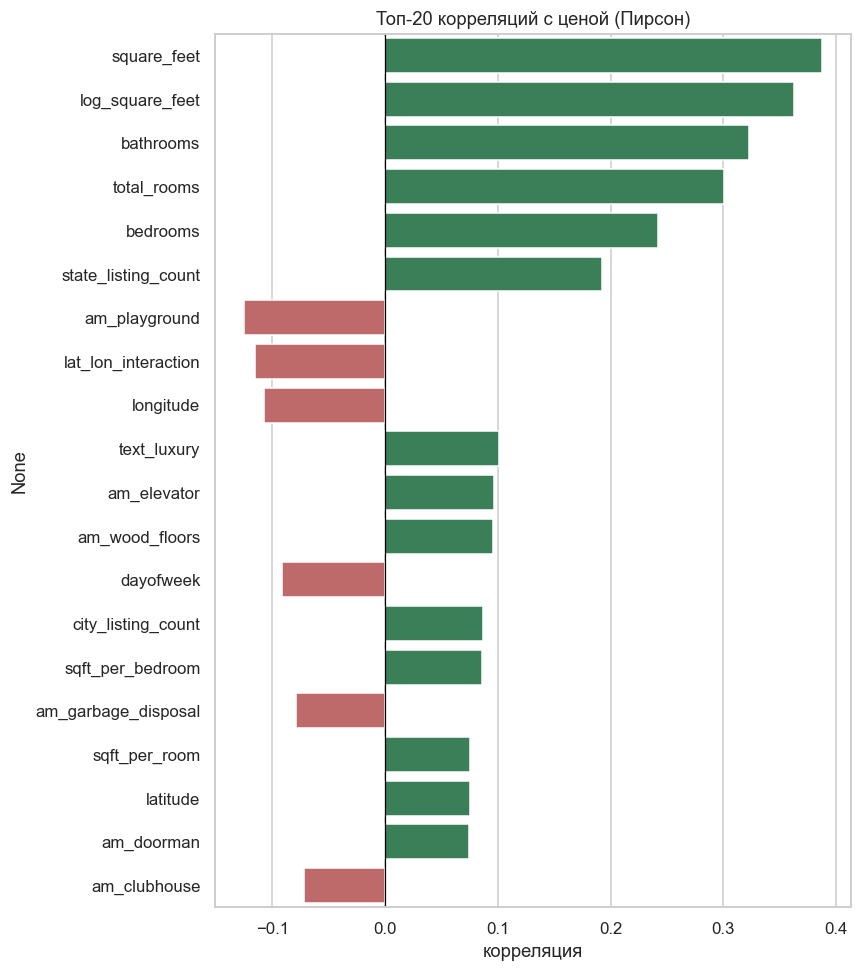

In [10]:
plots.plot_correlations(df);

Сильнее всего с ценой связаны площадь, число санузлов и количество удобств.
Отдельные удобства вроде `Doorman` и `Elevator` дают сдвиг медианной цены на сотни долларов —
но это скорее маркер дорогого городского сегмента, чем самостоятельная причина цены.

## 4. Сплит

В EDA мы видели, что около трети строк совпадают по набору
«координаты + площадь + спальни + санузлы» — это повторные подачи одного объекта.
Проверим, насколько случайный сплит завышает качество.

In [11]:
features = numeric + categorical
comparison = {}

for group_aware in [False, True]:
    label = "групповой сплит" if group_aware else "наивный сплит"
    train, val, test = split_data(df, group_aware=group_aware)
    leakage = check_leakage(train, test)

    model = build_models(numeric, categorical)["knn_10"]
    model.fit(train[features], train[TARGET])
    metrics = compute_metrics(val[TARGET].to_numpy(), model.predict(val[features]))

    comparison[label] = {**metrics, "общих групп train/test": leakage["shared_groups"]}
    print(f"{label:18s} {format_metrics(metrics)} | пересечений: {leakage['shared_groups']}")

pd.DataFrame(comparison).T.round(3)

20:42:08 | INFO    | src.data.split | train  63376 строк (64.0%) | средняя цена 1513
20:42:08 | INFO    | src.data.split | val    15844 строк (16.0%) | средняя цена 1506
20:42:08 | INFO    | src.data.split | test   19805 строк (20.0%) | средняя цена 1523
20:42:08 | INFO    | src.data.split | Проверка утечки: {'shared_groups': 6613, 'shared_dedup_keys': 6613}
наивный сплит      MAE=302.2$ | RMSE=486.2$ | MAPE=21.3% | R2=0.577 | пересечений: 6613
20:42:10 | INFO    | src.data.split | train  62914 строк (63.5%) | средняя цена 1518
20:42:10 | INFO    | src.data.split | val    16223 строк (16.4%) | средняя цена 1509
20:42:10 | INFO    | src.data.split | test   19888 строк (20.1%) | средняя цена 1504
20:42:10 | INFO    | src.data.split | Проверка утечки: {'shared_groups': 0, 'shared_dedup_keys': 0}
групповой сплит    MAE=322.8$ | RMSE=499.4$ | MAPE=22.9% | R2=0.562 | пересечений: 0


,mae,rmse,mape,r2,median_ae,общих групп train/test
наивный сплит,302.168,486.159,21.321,0.577,192.4,6613.0
групповой сплит,322.829,499.368,22.893,0.562,214.7,0.0


**Результат.** При обычнос сплите 6 613 групп объектов оказываются одновременно в train и в test,
и KNN показывает MAE 302 \$ вместо 323 \$ — качество завышено примерно на 7%.
Модель просто находит в обучающей выборке ту же самую квартиру

Поэтому в `split_data` по умолчанию `group_aware=True` объявления об одном объекте целиком
уходят в одну часть выборки. Проверка `check_leakage` возвращает нули... так и надо

test 20%, val 20% от оставшегося, train ~64%. Валидация нужна отдельно от теста

In [12]:
train, val, test = split_data(df)
check_leakage(train, test)

# Распределение цены должно быть похожим во всех трёх частях
pd.DataFrame({
    part_name: part[TARGET].describe()
    for part_name, part in [("train", train), ("val", val), ("test", test)]
}).round(1)

20:42:11 | INFO    | src.data.split | train  62914 строк (63.5%) | средняя цена 1518
20:42:11 | INFO    | src.data.split | val    16223 строк (16.4%) | средняя цена 1509
20:42:11 | INFO    | src.data.split | test   19888 строк (20.1%) | средняя цена 1504
20:42:11 | INFO    | src.data.split | Проверка утечки: {'shared_groups': 0, 'shared_dedup_keys': 0}


,train,val,test
count,62914.0,16223.0,19888.0
mean,1518.1,1508.9,1503.9
std,756.1,754.2,775.6
min,200.0,264.0,300.0
25%,1014.0,1010.0,1010.0
50%,1356.0,1349.0,1333.0
75%,1795.0,1795.0,1770.0
max,10000.0,10000.0,10000.0


## 5. Выбор метрики

**Основная метрика — MAE (средняя абсолютная ошибка в долларах).**

Почему именно она:

1. **Интерпретируемость.** MAE = 320 \$ означает буквально «модель в среднем ошибается
   на 320 долларов в месяц». Это можно сказать заказчику без объяснения, что такое квадрат ошибки.
2. **Устойчивость к выбросам.** Распределение цены скошено вправо, и даже после отсечения
   границами остаётся тяжёлый хвост. RMSE в такой ситуации определяется несколькими самыми
   дорогими объявлениями, а не типичным качеством.
3. **Соответствие задаче.** Ошибка в 200 \$ на квартире за 1000 \$ и на квартире за 1200 \$
   одинаково неприятна для пользователя — линейный штраф здесь честнее квадратичного.

**Дополнительные метрики:**

- **RMSE** — смотрим на разрыв с MAE: чем он больше, тем чаще модель допускает крупные промахи.
- **MAPE** — относительная ошибка, нужна чтобы сравнить качество на дешёвом и дорогом сегментах:
  ошибка в 300 \$ — это катастрофа для студии за 600 \$ и мелочь для пентхауса за 8000 \$.

**Если метрики противоречат друг другу**, приоритет у MAE: финальную модель выбираем по ней.

Дополнительно смотрим MAE по ценовым квантилям (`evaluate.error_analysis`) — средняя цифра
скрывает, что дорогой сегмент предсказывается заметно хуже.

## 6. Итог

- Очистка убрала 0.47% строк, пропусков не осталось
- Признаков стало 55 числовых + 5 категориальных вместо 5 исходных числовых
- Найдены и устранены два канала утечки таргета колонка `price_display`
  и цена в тексте объявления
- Сплит групповой, пересечений между train и test — ноль
- Основная метрика — MAE в долларах, обоснование выше

Дальше — ноутбук 03